## Ridge and Lasso Regression Practical Implementation

In [1]:
import pandas as pd
from sklearn.datasets import load_boston

In [2]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = load_boston()

data_set = pd.DataFrame(df.data, columns=df.feature_names)
data_set.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33


#### x and y seperation

In [4]:
x = data_set
y = df.target

In [5]:
x

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1.0,273.0,21.0,391.99,9.67
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1.0,273.0,21.0,396.90,9.08
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1.0,273.0,21.0,396.90,5.64
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1.0,273.0,21.0,393.45,6.48


In [6]:
# Split data into training and testing set

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.30, random_state=45)

In [7]:
print("Shape of x_train: ",x_train.shape)
print("Shape of y_train: ",y_train.shape)
print("----------------------------")
print("Shape of y_train: ",x_test.shape)
print("Shape of y_train: ",y_test.shape)

Shape of x_train:  (354, 13)
Shape of y_train:  (354,)
----------------------------
Shape of y_train:  (152, 13)
Shape of y_train:  (152,)


In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.metrics import r2_score

The process of Cross Validation:
1. The data is divided into k equal-sized part (or "folds")
2. The model is trained on k-1 fold and test on the ramaining folds or chunks.
3. This process is repeated k times, with a different fold used as the test set each time.
4. The performance metrics (like accuracy, precious etc) are averaged over the k runs to give a more reliable estimate.


Ex:
1. split data into 5 chunks: ABCDE
2. Train on BCDE and test on A
3. Train on ACDE and test on B
4. Train on ABDE and test on C
5. Train on ABCE and test on D
6. Train on ABCD and test on E
7. Average the 5 performance scores.

In [9]:
# Standerdizing dataset
st = StandardScaler()
x_train = st.fit_transform(x_train)
x_test = st.transform(x_test)

## Learning Regression

In [10]:
lr = LinearRegression()
lr.fit(x_train,y_train)

LinearRegression()

In [11]:
scores = cross_val_score(lr, x_train, y_train, scoring='neg_mean_squared_error', cv=6)
scores

array([-13.88435895, -38.57571969, -25.81864782, -14.8008486 ,
       -21.9735737 , -28.07983764])

In [12]:
np.mean(scores)

-23.855497734567127

In [13]:
reg_pred = lr.predict(x_test) # prediction

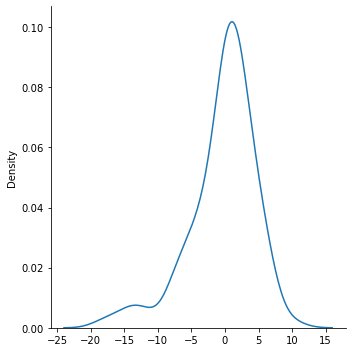

In [14]:
sns.displot(reg_pred-y_test, kind='kde')

In [15]:
r2_score(reg_pred, y_test)

0.624971333850757

## Ridge Regression

In [19]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

In [ ]:
ridge_reg = Ridge()
ridge_reg

Ridge()

In [25]:
parameters = {'alpha':[1,2,3,4,5,6,7,8,9,10,11,15,16,21]}

In [26]:
ridge_cv = GridSearchCV(estimator=ridge_reg, param_grid=parameters, scoring='neg_mean_squared_error', cv=5)
ridge_cv.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 15, 16,
                                   21]},
             scoring='neg_mean_squared_error')

In [27]:
ridge_cv.best_params_

{'alpha': 9}

In [28]:
ridge_cv.best_score_

-23.973755831714517

In [29]:
ridge_predict = ridge_cv.predict(x_test)
ridge_predict

array([10.24077852, 23.94408537, 24.74252612, 21.35005045, 34.83334255,
       14.2307035 , 19.54481072, 18.93413505, 27.35685155, 17.36735735,
       14.76796514, 19.91743981, 36.33994706, 23.44294355, 15.93457062,
       20.24384697, 27.81965247, 11.5018548 , 15.86533826, 22.37889979,
       22.45095226, 14.80363844, 21.02362107, 32.33918756, 22.62307993,
       27.58945243, 22.99578686,  7.8268257 , 25.96916047, 19.56822465,
       21.35171499,  8.53155374, 28.26654225, 24.94735491, 35.54983393,
       25.73949896, 39.13588418,  2.15385857, 30.84144742, 32.14910407,
       19.6299205 , 21.99963425, 17.16705362, 30.68191965, 19.16184176,
       18.36312324, 28.41239097, 28.05646636, 18.77009267, 21.26605002,
       41.83882717, 16.94680107, 27.73946836, 34.81894454, 16.59896012,
       30.50806364,  6.17054458, 13.91129114, 18.92509697, 19.782865  ,
       14.2277831 , 18.18938824, 36.38882184, 35.10180532, 17.65147362,
       13.32006159, 38.18993456, 36.07304758, 13.83117597, 19.84

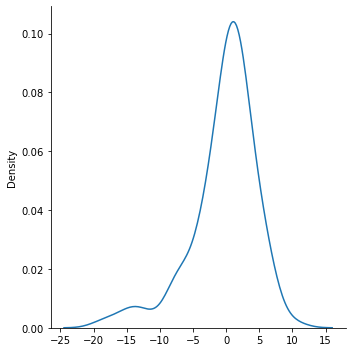

In [31]:
sns.displot(ridge_predict-y_test, kind='kde')

In [34]:
r2_score(ridge_predict, y_test)   # this is due to we have very small data.
                                    # otherwise we ridge to overcome from overfitting issue

0.6046022701341596

## Lasso Regression

In [35]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV

In [36]:
lasso_reg = Lasso()
lasso_reg

Lasso()

In [38]:
lasso_cv = GridSearchCV(estimator=lasso_reg, param_grid=parameters, scoring='neg_mean_squared_error', cv=5)
lasso_cv.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=Lasso(),
             param_grid={'alpha': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 15, 16,
                                   21]},
             scoring='neg_mean_squared_error')

In [39]:
lasso_cv.best_params_

{'alpha': 1}

In [41]:
lasso_cv.best_score_

-29.2073179468256

In [44]:
lasso_predict = lasso_cv.predict(x_test)
lasso_predict

array([11.05897913, 27.82159154, 24.36380267, 22.42486817, 32.54108315,
       14.13064651, 20.83366625, 19.85368327, 26.91265675, 18.59352383,
       17.96302785, 19.81211299, 34.193973  , 20.07528952, 15.48385078,
       22.01835154, 26.54536857, 11.19279397, 16.44872685, 24.04854902,
       22.50814953, 20.42447077, 27.0855408 , 30.17026638, 22.67284461,
       27.0818683 , 22.22209304, 11.43117993, 25.65652154, 19.6178219 ,
       22.03716736,  8.96941399, 29.22045362, 24.46405391, 34.32697876,
       25.36610679, 34.32274119,  4.25123101, 27.29996046, 29.43125528,
       18.54506576, 19.14565988, 17.54529816, 27.86023741, 20.64542549,
       18.30315477, 26.58127001, 27.36909298, 20.18397541, 20.1779675 ,
       35.95828376, 22.60606612, 25.57861376, 30.98522914, 18.36021249,
       25.70394172,  7.38063222, 15.22431765, 18.30563367, 20.25979218,
       16.28548872, 18.11218831, 32.98827425, 30.57336192, 18.68527255,
       16.546169  , 34.6315963 , 35.01163997, 13.81644259, 21.56

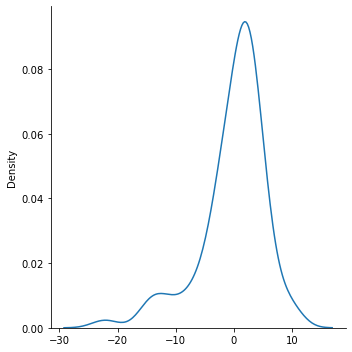

In [45]:
sns.displot(lasso_predict-y_test, kind='kde')